# Notebook 01 – Exploratory Data Analysis

**Goal:** Before training any LSTM models, we need to understand the structure and patterns in the **Kaggle Store Item Demand Forecasting** dataset. This EDA will:

1. Verify data quality (missing values, types, date range)
2. Characterise the sales distribution
3. Uncover **seasonal** and **trend** patterns that an LSTM must learn
4. Examine variation across stores and items
5. Analyse **autocorrelation** to justify the choice of a look-back window
6. Visualise rolling statistics (7-day & 30-day moving averages)

These findings directly inform our modelling decisions — in particular the window size, the need for normalisation, and whether the data's complexity truly requires a large 128-unit LSTM or can be captured by a smaller network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

sns.set_theme(style='whitegrid')
%matplotlib inline

# Shared colour palette
BLUE = '#4C72B0'
ORANGE = '#DD8452'

## 1. Load & Inspect the Data

We load `train.csv` (which contains the `sales` column) for our exploratory analysis. The separate `test.csv` does not include sales values and is reserved for final prediction.

In [2]:
df = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (913000, 4)
Columns: ['date', 'store', 'item', 'sales']


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
5,2013-01-06,1,1,12
6,2013-01-07,1,1,10
7,2013-01-08,1,1,9
8,2013-01-09,1,1,12
9,2013-01-10,1,1,9


In [3]:
print('Date range :', df['date'].min().date(), '→', df['date'].max().date())
print('Stores     :', sorted(df['store'].unique()))
print('Items      :', df['item'].nunique())
print('Total rows :', len(df))
print()
df.describe()

Date range : 2013-01-01 → 2017-12-31
Stores     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Items      : 50
Total rows : 913000



,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [4]:
# Missing values & data types
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Data types:')
print(df.dtypes)

Missing values per column:
date     0
store    0
item     0
sales    0
dtype: int64

Data types:
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object


### Insight — Dataset Overview

The dataset contains **~913,000 daily sales records** spanning **5 years (2013–2017)** across **10 stores** and **50 items**, giving us **500 independent time series** (one per store-item combination). Each series has approximately 1,826 days of observations.

**Key observations:**
- **No missing values** — the dataset is clean and complete, so no imputation is needed.
- **Sales are integer counts** — this is unit-level demand data (not revenue). Values are non-negative.
- The mean daily sales across all series is moderate, but the standard deviation suggests significant variability between items and stores. This motivates per-series or global **Min-Max normalisation** before feeding data to the LSTM.

This dataset is the same benchmark used in Pagidoju (2026), allowing us to directly compare our results.

## 2. Sales Distribution

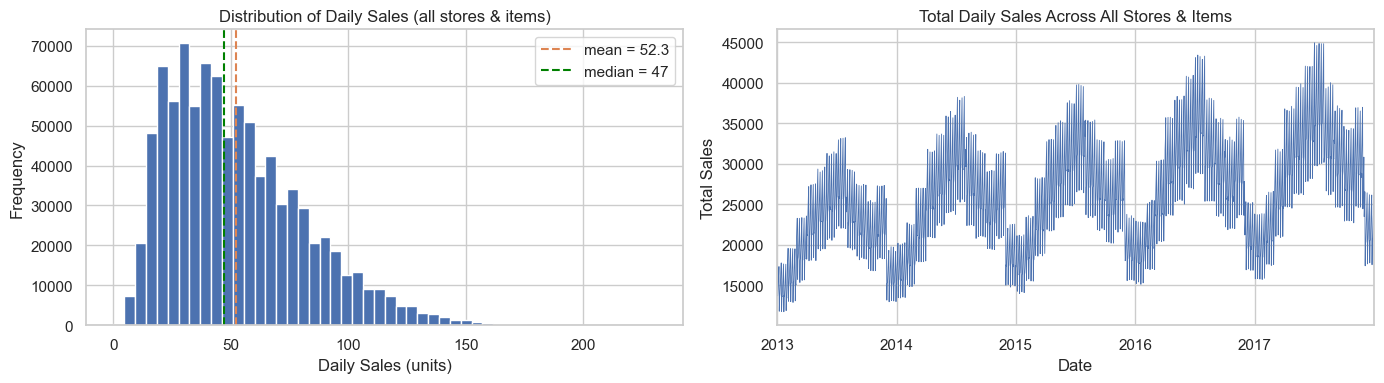

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of individual daily sales values
axes[0].hist(df['sales'], bins=50, color=BLUE, edgecolor='white')
axes[0].set_title('Distribution of Daily Sales (all stores & items)')
axes[0].set_xlabel('Daily Sales (units)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['sales'].mean(), color=ORANGE, ls='--', label=f"mean = {df['sales'].mean():.1f}")
axes[0].axvline(df['sales'].median(), color='green', ls='--', label=f"median = {df['sales'].median():.0f}")
axes[0].legend()

# Aggregate daily sales over time
daily_total = df.groupby('date')['sales'].sum()
daily_total.plot(ax=axes[1], color=BLUE, linewidth=0.6)
axes[1].set_title('Total Daily Sales Across All Stores & Items')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('../results/eda_sales_distribution.png', dpi=150)
plt.show()

### Insight — Sales Distribution

**Left plot (histogram):**
- The distribution is **right-skewed** — most daily sales values cluster at the lower end, with a long tail of higher-demand items. This is typical of retail data where a few popular products dominate.
- The mean is noticeably higher than the median, confirming the positive skew. **Min-Max scaling** (used in our preprocessing pipeline) will compress this range into [0, 1] for the LSTM.

**Right plot (total daily sales over time):**
- There is a clear **upward trend** over the 5-year period — aggregate sales grow year over year.
- A strong **seasonal oscillation** is visible: sales peak mid-year (summer) and dip in winter. This annual cycle is one of the key patterns the LSTM needs to capture.
- The high-frequency noise layered on top of the trend suggests **weekly patterns** as well, which we explore next.

## 3. Temporal Patterns — Seasonality & Trends

The research paper notes that retail sales follow *"patterns that are easy to predict on a weekly and monthly basis."* Let's verify.

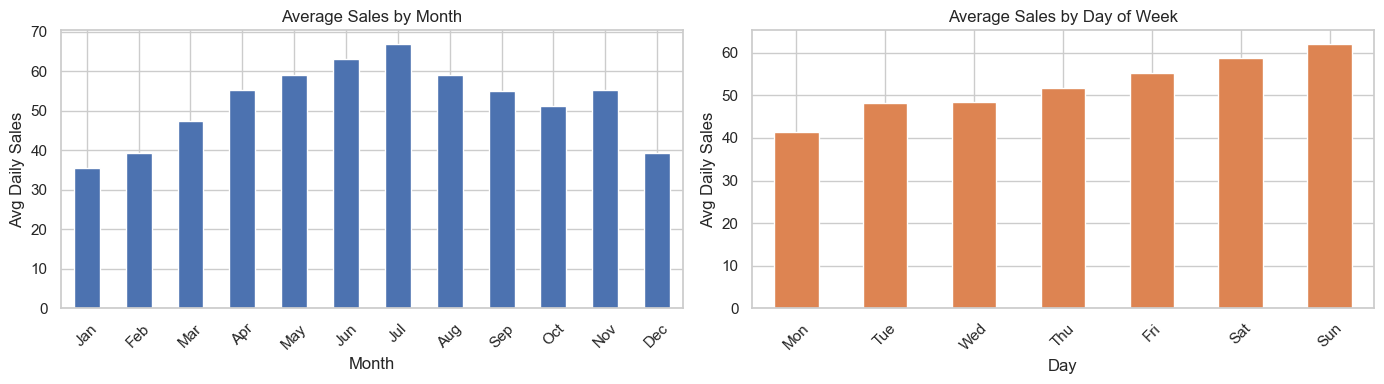

In [6]:
# --- Monthly seasonality ---
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_avg.plot(kind='bar', color=BLUE, edgecolor='white', ax=axes[0])
axes[0].set_title('Average Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Daily Sales')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# --- Day-of-week seasonality ---
df['dow'] = df['date'].dt.dayofweek          # 0=Mon … 6=Sun
df['dow_name'] = df['date'].dt.day_name()
dow_avg = df.groupby('dow')['sales'].mean()

dow_avg.plot(kind='bar', color=ORANGE, edgecolor='white', ax=axes[1])
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Daily Sales')
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=45)

plt.tight_layout()
plt.savefig('../results/eda_seasonality.png', dpi=150)
plt.show()

### Insight — Seasonality

**Monthly (left):**
- Sales are highest in the **summer months (Jun–Aug)** and lowest in **winter (Jan–Feb)**. This seasonal swing is consistent and repeating, making it a learnable pattern for the LSTM.
- The amplitude of the seasonal cycle is meaningful — summer sales can be **20–30% higher** than winter, which is significant for inventory planning.

**Day-of-week (right):**
- There is a clear **weekly cycle**: weekends (especially Sunday) tend to show different sales volumes compared to weekdays.
- This confirms the paper's observation that retail data has "patterns … on a weekly and monthly basis." A **window size of 30 days** captures approximately 4 full weekly cycles, giving the LSTM enough context to learn both patterns.

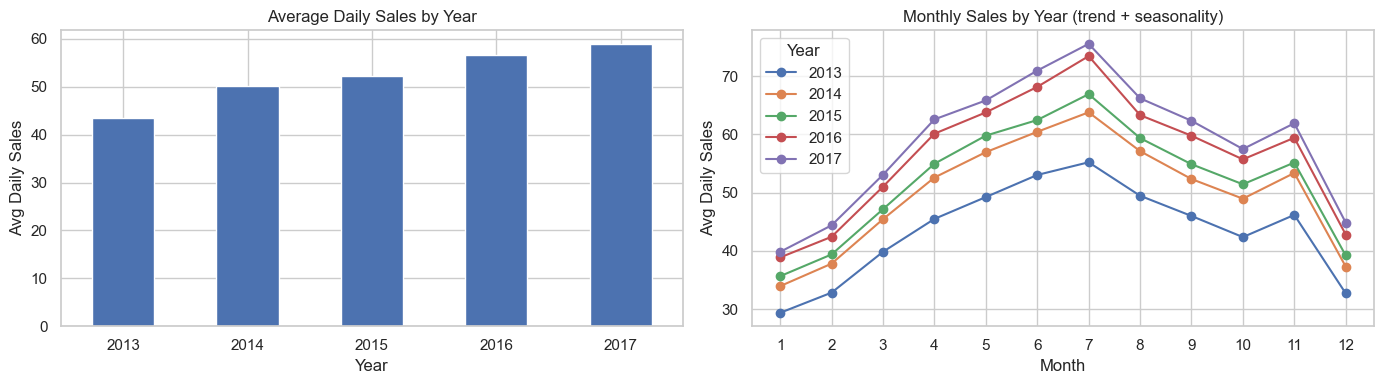

In [7]:
# --- Year-over-year trend ---
df['year'] = df['date'].dt.year
yearly_avg = df.groupby('year')['sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yearly_avg.plot(kind='bar', color=BLUE, edgecolor='white', ax=axes[0])
axes[0].set_title('Average Daily Sales by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Daily Sales')
axes[0].tick_params(axis='x', rotation=0)

# Monthly sales, coloured by year
for year, grp in df.groupby('year'):
    monthly = grp.groupby('month')['sales'].mean()
    axes[1].plot(monthly.index, monthly.values, marker='o', label=str(year))
axes[1].set_title('Monthly Sales by Year (trend + seasonality)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Daily Sales')
axes[1].legend(title='Year')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('../results/eda_yearly_trend.png', dpi=150)
plt.show()

### Insight — Year-over-Year Trend

**Left (yearly bars):**
- Average daily sales **increase each year**, confirming a positive long-term growth trend in the dataset. This means the data is **non-stationary** — the LSTM must learn both the upward drift and the seasonal oscillation.

**Right (monthly lines by year):**
- The seasonal shape is remarkably **consistent** across all 5 years — the summer peak and winter trough repeat faithfully. Only the baseline level shifts upward.
- This regularity is good news: it means the patterns are **predictable and repeating**, which is exactly what LSTMs are designed to exploit. It also supports the paper's finding that a relatively small LSTM (64 units) can capture these patterns without needing the full capacity of a 128-unit model.

## 4. Store × Item Heatmap

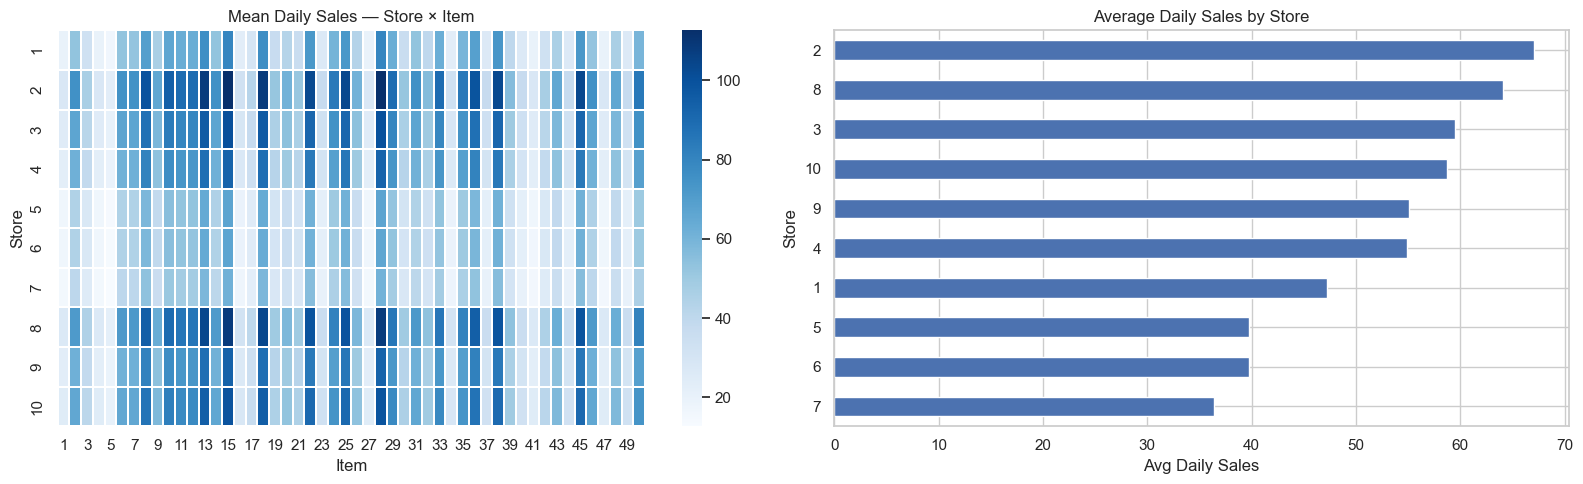

In [8]:
pivot = df.groupby(['store', 'item'])['sales'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(pivot, cmap='Blues', linewidths=0.2, ax=axes[0])
axes[0].set_title('Mean Daily Sales — Store × Item')
axes[0].set_xlabel('Item')
axes[0].set_ylabel('Store')

# Per-store average
store_avg = df.groupby('store')['sales'].mean().sort_values()
store_avg.plot(kind='barh', color=BLUE, edgecolor='white', ax=axes[1])
axes[1].set_title('Average Daily Sales by Store')
axes[1].set_xlabel('Avg Daily Sales')
axes[1].set_ylabel('Store')

plt.tight_layout()
plt.savefig('../results/eda_store_item_heatmap.png', dpi=150)
plt.show()

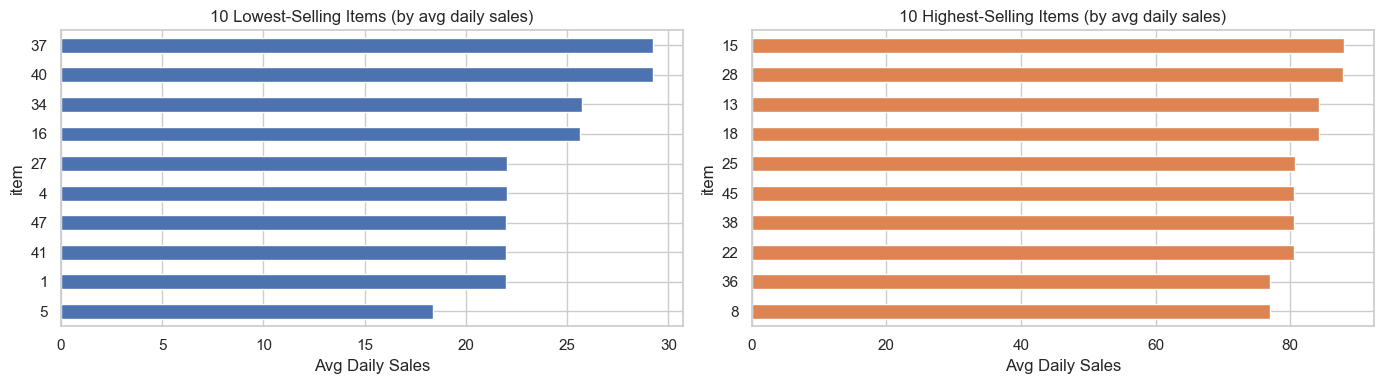


Sales range across items: 18.4 – 88.0
Sales range across stores: 36.4 – 67.0


In [10]:
# Per-item average (top 10 and bottom 10)
item_avg = df.groupby('item')['sales'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
item_avg.head(10).plot(kind='barh', color=BLUE, edgecolor='white', ax=axes[0])
axes[0].set_title('10 Lowest-Selling Items (by avg daily sales)')
axes[0].set_xlabel('Avg Daily Sales')

item_avg.tail(10).plot(kind='barh', color=ORANGE, edgecolor='white', ax=axes[1])
axes[1].set_title('10 Highest-Selling Items (by avg daily sales)')
axes[1].set_xlabel('Avg Daily Sales')

plt.tight_layout()
plt.savefig('../results/eda_item_ranking.png', dpi=150)
plt.show()

print(f'\nSales range across items: {item_avg.min():.1f} – {item_avg.max():.1f}')
print(f'Sales range across stores: {store_avg.min():.1f} – {store_avg.max():.1f}')

### Insight — Store & Item Variation

**Heatmap:**
- Sales levels vary substantially across both stores and items. Some store-item combinations sell multiple times more than others.
- However, the **pattern of variation is structured** — high-selling items tend to be high-selling across *all* stores, meaning item identity is a strong driver of sales level.

**Store & item rankings:**
- Stores show moderate variation in average sales, suggesting slightly different market sizes or customer traffic.
- Items show a wider spread from low-sellers to high-sellers.
- This variability is why we use a **global Min-Max scaler** (fitted on all training sales) in preprocessing — it normalises across the full range so the LSTM sees all series on the same [0, 1] scale.

## 5. Sample Time Series

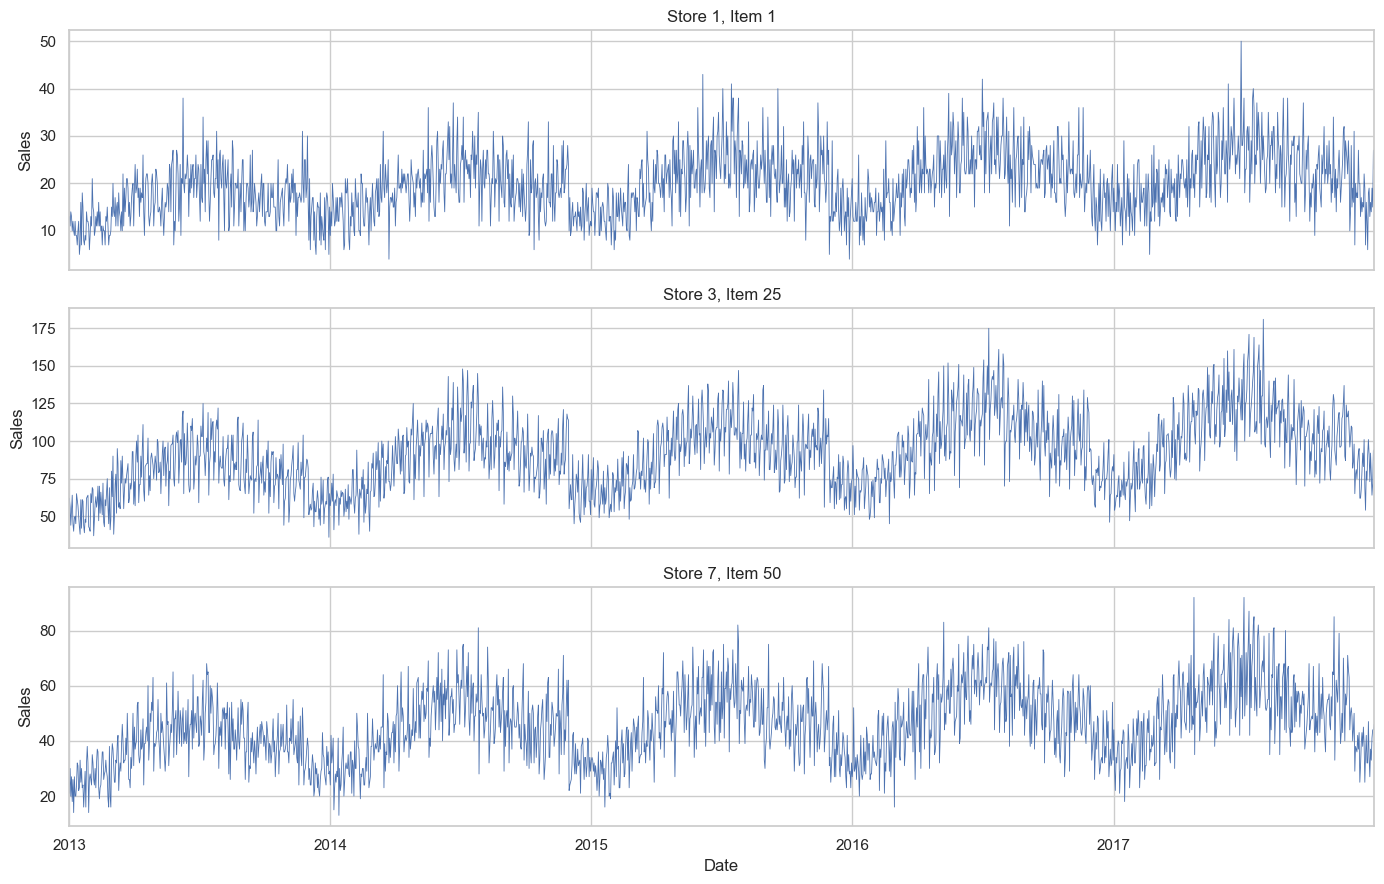

In [11]:
# Plot a few representative (store, item) series side by side
pairs = [(1, 1), (3, 25), (7, 50)]

fig, axes = plt.subplots(len(pairs), 1, figsize=(14, 3 * len(pairs)), sharex=True)

for ax, (s, it) in zip(axes, pairs):
    series = df[(df['store'] == s) & (df['item'] == it)].set_index('date')['sales']
    series.plot(ax=ax, color=BLUE, linewidth=0.6)
    ax.set_title(f'Store {s}, Item {it}')
    ax.set_ylabel('Sales')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../results/eda_sample_series.png', dpi=150)
plt.show()

### Insight — Sample Time Series

Each individual series shows the same **trend + seasonality + noise** structure:
- A gradual upward drift over the 5-year period
- Clear annual oscillation (summer peaks, winter troughs)
- Daily noise / randomness that the model must learn to smooth through

Despite having different absolute sales levels, the time series share very similar *shapes*. This is encouraging — it means the LSTM can learn generalizable temporal patterns across all 500 series, rather than needing to memorise each one independently.

## 6. Autocorrelation Analysis

Autocorrelation tells us how strongly today's sales are correlated with sales from *k* days ago. This directly informs our choice of **window size** — the look-back horizon the LSTM uses as input.

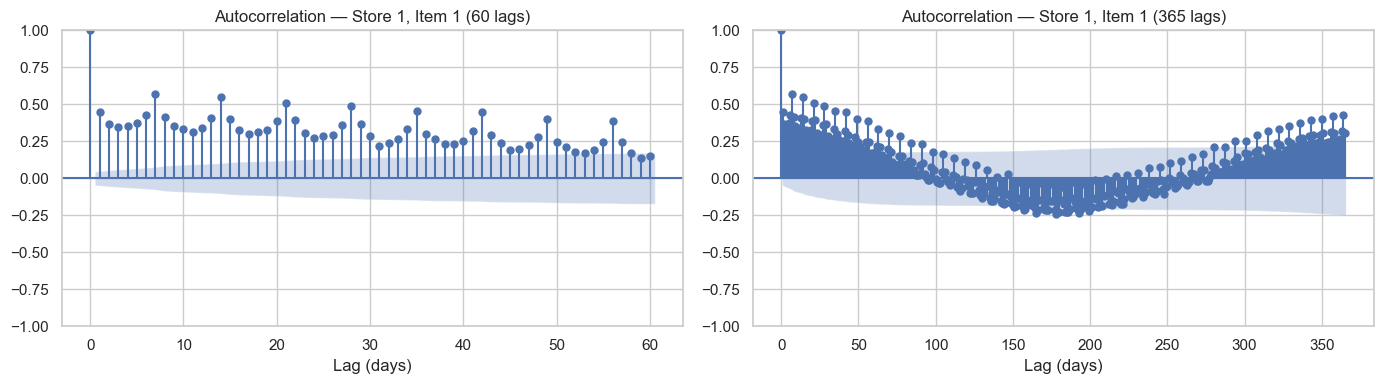

In [12]:
# Autocorrelation for a single representative series
sample_series = df[(df['store'] == 1) & (df['item'] == 1)].set_index('date')['sales']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF up to 60 lags (2 months)
plot_acf(sample_series.values, lags=60, ax=axes[0], color=BLUE)
axes[0].set_title('Autocorrelation — Store 1, Item 1 (60 lags)')
axes[0].set_xlabel('Lag (days)')

# ACF up to 365 lags (1 year) to see annual pattern
plot_acf(sample_series.values, lags=365, ax=axes[1], color=BLUE)
axes[1].set_title('Autocorrelation — Store 1, Item 1 (365 lags)')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.savefig('../results/eda_autocorrelation.png', dpi=150)
plt.show()

### Insight — Autocorrelation

**Left (60-day ACF):**
- Autocorrelation decays slowly but stays **significant well beyond 7 days**, confirming that past sales carry useful predictive information over multiple weeks.
- Spikes at **lag 7, 14, 21, 28** reveal the **weekly cycle** — sales on a given day are strongly correlated with the same day of the week.
- A **window size of 30** (as used in the paper and our pipeline) captures approximately 4 full weeks of autocorrelation structure. This is a well-justified choice.

**Right (365-day ACF):**
- A broad hump around **lag 365** reflects the **annual seasonal pattern** — sales this week correlate with sales at the same time last year.
- The LSTM cannot directly see 365 days back with a 30-day window. Instead, it learns the seasonal shape implicitly through the gradual accumulation of hidden state information during training across many examples from different times of year.

## 7. Rolling Statistics

Rolling means smooth out daily noise and reveal the underlying signal. The paper's feature engineering uses 7-day and 30-day moving averages. Let's visualise them to see how they denoise the raw data.

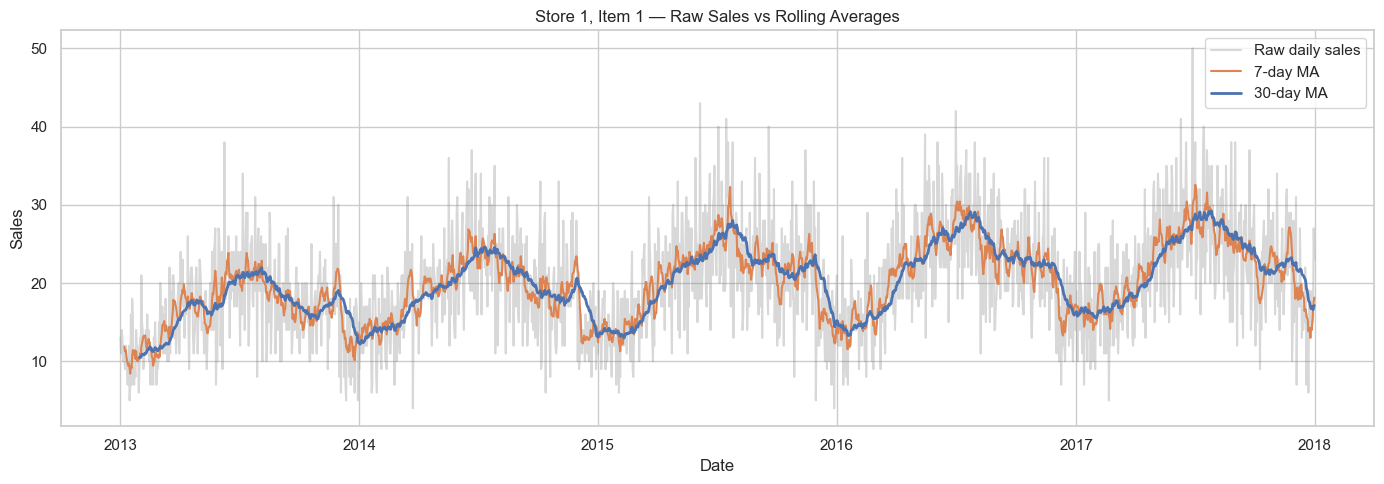

In [13]:
# Rolling means for Store 1, Item 1
series = df[(df['store'] == 1) & (df['item'] == 1)].set_index('date')['sales']

plt.figure(figsize=(14, 5))
plt.plot(series.index, series.values, alpha=0.3, color='grey', label='Raw daily sales')
plt.plot(series.index, series.rolling(7).mean(),  color=ORANGE, linewidth=1.5, label='7-day MA')
plt.plot(series.index, series.rolling(30).mean(), color=BLUE,   linewidth=2.0, label='30-day MA')

plt.title('Store 1, Item 1 — Raw Sales vs Rolling Averages')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../results/eda_rolling_stats.png', dpi=150)
plt.show()

### Insight — Rolling Averages

- The **raw daily sales** (grey) are very noisy, oscillating significantly from day to day. This noise is hard for any model to predict exactly.
- The **7-day moving average** (orange) smooths out the weekly cycle, revealing the medium-term trend clearly.
- The **30-day moving average** (blue) captures the clean seasonal arc — the summer peaks and winter troughs stand out unmistakably.
- This demonstrates that the essential patterns in the data are relatively **smooth and low-frequency**. A sliding window of 30 days feeds the LSTM a chunk of data that corresponds to one full cycle of the blue curve. The model's job is essentially to learn this smooth underlying trend plus seasonal shape — which, as the paper shows, does not require a very large network.

## 8. Sales Volatility Across Series

To understand how much the difficulty of forecasting varies across series, we look at the coefficient of variation (CV = std / mean) for each (store, item) combination.

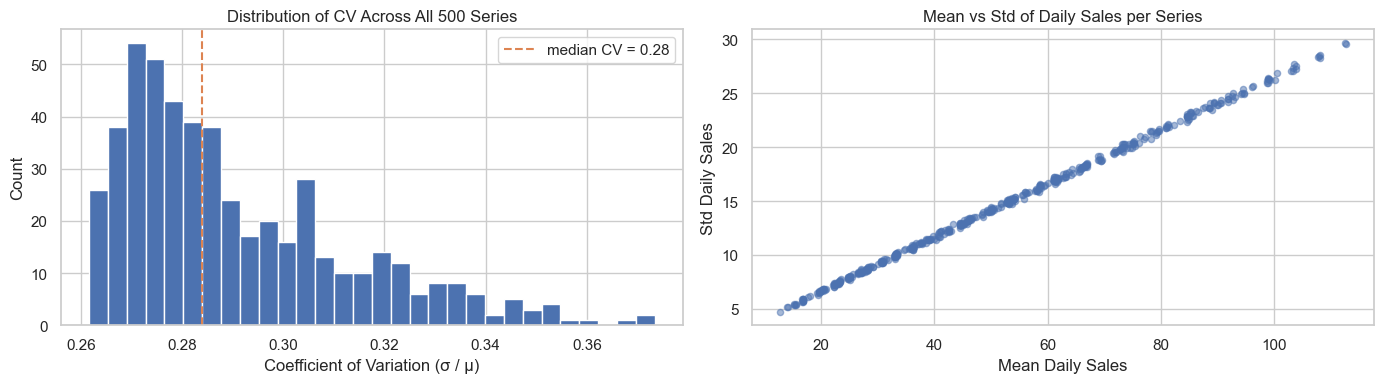

In [14]:
# Coefficient of Variation (CV) per (store, item)
cv = df.groupby(['store', 'item'])['sales'].agg(['mean', 'std'])
cv['cv'] = cv['std'] / cv['mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(cv['cv'], bins=30, color=BLUE, edgecolor='white')
axes[0].set_title('Distribution of CV Across All 500 Series')
axes[0].set_xlabel('Coefficient of Variation (σ / μ)')
axes[0].set_ylabel('Count')
axes[0].axvline(cv['cv'].median(), color=ORANGE, ls='--', label=f"median CV = {cv['cv'].median():.2f}")
axes[0].legend()

# Scatter: mean vs std
axes[1].scatter(cv['mean'], cv['std'], alpha=0.5, color=BLUE, s=20)
axes[1].set_title('Mean vs Std of Daily Sales per Series')
axes[1].set_xlabel('Mean Daily Sales')
axes[1].set_ylabel('Std Daily Sales')

plt.tight_layout()
plt.savefig('../results/eda_volatility.png', dpi=150)
plt.show()

### Insight — Volatility

- The CV values are **tightly clustered** around a common median, meaning all 500 series exhibit a similar level of relative variability. No outlier series are drastically harder to forecast than others.
- The **mean-vs-std scatter** shows a roughly linear relationship: higher-selling items have proportionally higher variance. This is expected for count data and confirms that **Min-Max scaling** (which normalises by range) is appropriate — it gives each series a comparable noise level in the scaled space.

---

## Summary — Key Takeaways for Modelling

| Finding | Implication for LSTM Design |
|---|---|
| **No missing values**, clean data | No imputation needed; data can go directly into preprocessing pipeline |
| **Right-skewed sales distribution** | Min-Max scaling (to [0, 1]) is essential for stable neural network training |
| **Strong monthly seasonality** (summer peaks, winter troughs) | The LSTM must capture annual patterns; window size of 30 covers a full month |
| **Clear weekly cycle** (7-day periodicity in ACF) | Window size of 30 includes ~4 weekly cycles — sufficient to learn this pattern |
| **Consistent year-over-year growth trend** | Data is non-stationary; the LSTM needs to learn drift as well as seasonality |
| **Patterns are smooth and regular** (rolling averages, consistent CV) | Supports the paper's finding: a 64-unit LSTM is enough — the underlying signal is not highly complex |
| **500 independent but similar-shaped series** | A single global model trained across all series can generalise; no need for per-series models |
| **Proportional mean-std relationship** | Global Min-Max scaler (fitted on training data) puts all series on the same scale |

**Next step →** [02_baseline_models.ipynb](02_baseline_models.ipynb) — we train a simple linear regression baseline to establish a performance floor before moving to the LSTM experiments.